Finished U/t=0, g/t=1.5 in 2.89 s
Finished U/t=0, g/t=2 in 2.61 s
Finished U/t=0, g/t=3 in 2.23 s
Finished U/t=12, g/t=1.5 in 2.31 s
Finished U/t=12, g/t=2 in 2.45 s
Finished U/t=12, g/t=3 in 2.33 s
15.039901971817017 seconds


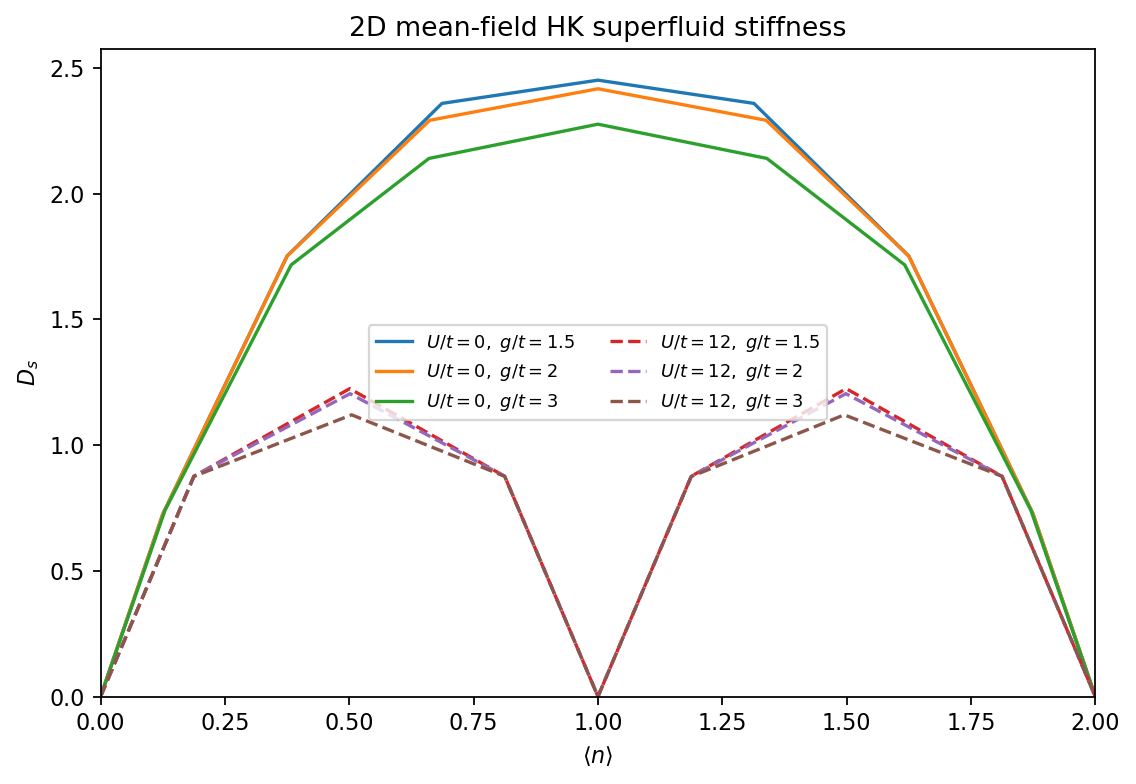

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy import optimize

start_time = time.time()
def lorentzian(x, gamma):
    """Normalized Lorentzian used to broaden delta functions."""
    return gamma / np.pi / (x**2 + gamma**2)


def state_index(occ):
    """Map |n_ku, n_kd, n_-ku, n_-kd> to the integer Fock index."""
    return sum(int(n) << i for i, n in enumerate(occ))


def annihilation_operator(mode, n_modes=4):
    """Fermionic annihilation matrix for one mode in the occupation basis."""
    dim = 2**n_modes
    op = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if not ((state >> mode) & 1):
            continue

        new_state = state & ~(1 << mode)
        occupied_before = sum((state >> j) & 1 for j in range(mode))
        sign = (-1) ** occupied_before
        op[new_state, state] = sign

    return op


def thermal_weights(energies, beta):
    """Boltzmann weights normalized in a numerically stable way."""
    shifted = energies - np.min(energies)
    weights = np.exp(-beta * shifted)
    return weights / np.sum(weights)


def block_matrix_elements(xi_k, U, Delta):
    """
    Construct the explicit block matrices derived from s_z and momentum
    conservation.

    Basis convention:
        |n_ku, n_kd, n_-ku, n_-kd>

    Mode order:
        0: k up
        1: k down
        2: -k up
        3: -k down
    """
    d = Delta
    dc = np.conjugate(Delta)

    h_sz_2 = np.array([[2.0 * xi_k]], dtype=complex)
    basis_sz_2 = [(1, 0, 1, 0)]

    h_sz_minus_2 = np.array([[2.0 * xi_k]], dtype=complex)
    basis_sz_minus_2 = [(0, 1, 0, 1)]

    h1 = np.array(
        [
            [xi_k, -dc],
            [-d, 3.0 * xi_k + U],
        ],
        dtype=complex,
    )

    basis_sz_1_a = [(1, 0, 0, 0), (1, 1, 1, 0)]
    basis_sz_1_b = [(0, 0, 1, 0), (1, 0, 1, 1)]

    basis_sz_minus_1_a = [(0, 1, 0, 0), (1, 1, 0, 1)]
    basis_sz_minus_1_b = [(0, 0, 0, 1), (0, 1, 1, 1)]

    h_sz_0_4 = np.array(
        [
            [0.0, dc, -dc, 0.0],
            [d, 2.0 * xi_k, 0.0, -dc],
            [-d, 0.0, 2.0 * xi_k, dc],
            [0.0, -d, d, 4.0 * xi_k + 2.0 * U],
        ],
        dtype=complex,
    )
    basis_sz_0_4 = [
        (0, 0, 0, 0),
        (1, 0, 0, 1),
        (0, 1, 1, 0),
        (1, 1, 1, 1),
    ]

    h_doublon = np.array([[2.0 * xi_k + U]], dtype=complex)
    basis_doublon_k = [(1, 1, 0, 0)]
    basis_doublon_minus_k = [(0, 0, 1, 1)]

    return [
        (h_sz_2, basis_sz_2),
        (h1, basis_sz_1_a),
        (h1, basis_sz_1_b),
        (h_sz_0_4, basis_sz_0_4),
        (h_doublon, basis_doublon_k),
        (h_doublon, basis_doublon_minus_k),
        (h1, basis_sz_minus_1_a),
        (h1, basis_sz_minus_1_b),
        (h_sz_minus_2, basis_sz_minus_2),
    ]


def diagonalize_sector_block(xi_k, U, Delta):
    """Diagonalize all blocks for a given xi_k and embed eigenvectors into 16D."""
    energies_all = []
    vectors_all = []

    for h_block, basis_occ in block_matrix_elements(xi_k, U, Delta):
        energies, vectors = np.linalg.eigh(h_block)
        basis_indices = [state_index(occ) for occ in basis_occ]

        for n in range(len(energies)):
            full_vector = np.zeros(16, dtype=complex)
            full_vector[basis_indices] = vectors[:, n]
            energies_all.append(energies[n])
            vectors_all.append(full_vector)

    order = np.argsort(np.real(energies_all))
    energies_all = np.array(energies_all, dtype=float)[order]
    vectors_all = np.array(vectors_all, dtype=complex).T[:, order]

    return energies_all, vectors_all


def sector_operators():
    """Return c operators and B = b_k + b_-k in the full occupation basis."""
    c = [annihilation_operator(i) for i in range(4)]
    b_total = c[3] @ c[0] + c[1] @ c[2]
    return c, b_total


C_OPS, B_TOTAL_OP = sector_operators()


def pair_expectation_block(xi_k, U, Delta, beta):
    """Thermal expectation value of b_k + b_-k for a specified xi_k."""
    energies, vectors = diagonalize_sector_block(xi_k, U, Delta)

    rho = thermal_weights(energies, beta)
    b_eigenbasis = vectors.conj().T @ B_TOTAL_OP @ vectors
    return np.sum(rho * np.diag(b_eigenbasis))


def solve_gap_block(k_positive, g, t, mu, U, beta, initial_delta=0.5, mixing=0.5, max_iter=200, tol=1e-10):

    def new_delta(delta):
        pair_avg = 0.5 * np.mean(
            [
                pair_expectation_block(-2.0 * t * np.cos(k) - mu, U, delta, beta)
                for k in k_positive
            ]
        )
        return float(np.real(-g * pair_avg))

    def gap_equation(delta):
        return new_delta(delta) - delta

    # Delta = 0 is always a solution. Search on the positive side for a
    # nonzero superconducting root.
    lower = 1e-10
    upper = max(abs(float(np.real(initial_delta))), 1e-4)
    max_upper = max(8.0 * abs(g), 8.0, upper)

    f_lower = gap_equation(lower)
    f_upper = gap_equation(upper)

    while f_lower * f_upper > 0.0 and upper < max_upper:
        upper *= 2.0
        f_upper = gap_equation(upper)

    if f_lower * f_upper > 0.0:
        return 0.0 + 0.0j

    result = optimize.root_scalar(gap_equation, bracket=(lower, upper), xtol=tol, rtol=tol)
    if not result.converged:
        return 0.0 + 0.0j

    return complex(result.root)


def spectral_function_for_k_block(k, omega_values, t, mu, U, Delta, beta, gamma, spin="up"):
    """
    Compute A_sigma(k, omega) using A = A_plus + A_minus and block
    diagonalization.
    """
    xi_k = -2.0 * t * np.cos(abs(k)) - mu
    energies, vectors = diagonalize_sector_block(xi_k, U, Delta)
    rho = thermal_weights(energies, beta)

    mode = 0 if spin == "up" else 1
    c_op = C_OPS[mode]
    cd_op = c_op.conj().T

    c_eigenbasis = vectors.conj().T @ c_op @ vectors
    cd_eigenbasis = vectors.conj().T @ cd_op @ vectors

    spectrum = np.zeros_like(omega_values, dtype=float)

    for m, e_m in enumerate(energies):
        for n, e_n in enumerate(energies):
            addition_weight = rho[m] * abs(cd_eigenbasis[n, m]) ** 2
            removal_weight = rho[m] * abs(c_eigenbasis[n, m]) ** 2

            spectrum += addition_weight * lorentzian(omega_values - (e_n - e_m), gamma)
            spectrum += removal_weight * lorentzian(omega_values + (e_n - e_m), gamma)

    return spectrum


def hk_superconducting_spectral_function_block(
    k_values,
    omega_values,
    t=1.0,
    mu=1.0,
    U=8.0,
    Delta=0.8,
    beta=50.0,
    gamma=0.06,
    spin="up",
):
    spectral_weight = np.zeros((len(omega_values), len(k_values)), dtype=float)

    for i, k in enumerate(k_values):
        spectral_weight[:, i] = spectral_function_for_k_block(
            k,
            omega_values,
            t=t,
            mu=mu,
            U=U,
            Delta=Delta,
            beta=beta,
            gamma=gamma,
            spin=spin,
        )

    return spectral_weight


def number_operators():
    """Return N, N_k, and N_-k operators in the full 16D basis."""
    cd = [op.conj().T for op in C_OPS]
    n = [cd[i] @ C_OPS[i] for i in range(4)]
    n_k = n[0] + n[1]
    n_minus_k = n[2] + n[3]
    return n_k + n_minus_k, n_k, n_minus_k


N_TOTAL_OP, N_K_OP, N_MINUS_K_OP = number_operators()


def square_lattice_xi(kx, ky, t, mu):
    """2D square-lattice xi_k for epsilon_k = -2t(cos kx + cos ky)."""
    return -2.0 * t * (np.cos(kx) + np.cos(ky)) - mu


def make_half_bz_grid(grid_n):
    """
    Midpoint grid for the 2D Brillouin zone.

    Selecting kx > 0 keeps one representative from each (k, -k) pair and
    avoids special self-inverse boundary points.
    """
    grid = -np.pi + (np.arange(grid_n) + 0.5) * (2.0 * np.pi / grid_n)
    kx_grid, ky_grid = np.meshgrid(grid, grid, indexing="ij")
    half_bz = kx_grid > 0.0
    return kx_grid[half_bz], ky_grid[half_bz]


def solve_gap_2d(kx_half, ky_half, g, t, mu, U, beta, initial_delta=0.5, tol=1e-10):
    """Self-consistent gap on a 2D half-BZ grid using scipy root_scalar."""
    xi_values = square_lattice_xi(kx_half, ky_half, t, mu)

    def new_delta(delta):
        pair_avg = 0.5 * np.mean(
            [pair_expectation_block(xi_k, U, delta, beta) for xi_k in xi_values]
        )
        return float(np.real(-g * pair_avg))

    def gap_equation(delta):
        return new_delta(delta) - delta

    lower = 1e-10
    upper = max(abs(float(np.real(initial_delta))), 1e-4)
    max_upper = max(8.0 * abs(g), 8.0, upper)

    f_lower = gap_equation(lower)
    f_upper = gap_equation(upper)

    while f_lower * f_upper > 0.0 and upper < max_upper:
        upper *= 2.0
        f_upper = gap_equation(upper)

    if f_lower * f_upper > 0.0:
        return 0.0 + 0.0j

    result = optimize.root_scalar(gap_equation, bracket=(lower, upper), xtol=tol, rtol=tol)
    if not result.converged:
        return 0.0 + 0.0j

    return complex(result.root)


def sector_stiffness_observables_2d(kx, ky, t, mu, U, Delta, beta):
    """Return <N>, <K_xx>, and current-current response for one 2D sector."""
    xi_k = square_lattice_xi(kx, ky, t, mu)
    energies, vectors = diagonalize_sector_block(xi_k, U, Delta)
    rho = thermal_weights(energies, beta)

    velocity = 2.0 * t * np.sin(kx)
    curvature = 2.0 * t * np.cos(kx)
    kxx_op = curvature * (N_K_OP + N_MINUS_K_OP)
    jx_op = velocity * (N_K_OP - N_MINUS_K_OP)

    n_eigenbasis = vectors.conj().T @ N_TOTAL_OP @ vectors
    kxx_eigenbasis = vectors.conj().T @ kxx_op @ vectors
    jx_eigenbasis = vectors.conj().T @ jx_op @ vectors

    n_expect = np.sum(rho * np.diag(n_eigenbasis)).real
    kxx_expect = np.sum(rho * np.diag(kxx_eigenbasis)).real

    paramagnetic = 0.0
    for m, e_m in enumerate(energies):
        for n, e_n in enumerate(energies):
            matrix_element = abs(jx_eigenbasis[n, m]) ** 2
            denom = e_n - e_m
            if abs(denom) < 1e-12:
                factor = beta * rho[m]
            else:
                factor = (rho[m] - rho[n]) / denom
            paramagnetic += matrix_element * factor

    return n_expect, kxx_expect, float(np.real(paramagnetic))


def superfluid_stiffness_2d(kx_half, ky_half, g, t, mu, U, beta, initial_delta=0.5):
    """Compute filling, D_s, and self-consistent gap on a 2D half-BZ grid."""
    Delta = solve_gap_2d(
        kx_half,
        ky_half,
        g=g,
        t=t,
        mu=mu,
        U=U,
        beta=beta,
        initial_delta=initial_delta,
    )

    n_values = []
    stiffness_values = []
    for kx, ky in zip(kx_half, ky_half):
        n_sector, kxx_sector, para_sector = sector_stiffness_observables_2d(
            kx, ky, t, mu, U, Delta, beta
        )
        n_values.append(n_sector)
        stiffness_values.append(kxx_sector - para_sector)

    filling = 0.5 * np.mean(n_values)
    ds_over_pi = 0.5 * np.mean(stiffness_values)
    return filling, np.pi * ds_over_pi, Delta


# Model and plotting parameters.
t = 1.0
beta = 1000.0
grid_n = 8
kx_half, ky_half = make_half_bz_grid(grid_n)

U_values = [0.0, 12.0]
g_values = [1.5, 2.0, 3.0]
mu_points = 17

plt.figure(figsize=(7.2, 5.0), dpi=160)

for U in U_values:
    # The 2D square-lattice band has epsilon_k in [-4t, 4t]. For U > 0,
    # fillings above <n> = 1 require mu to enter the upper Hubbard band.
    mu_upper = 8.0 * t if U == 0 else U + 12.0 * t
    mu_values = np.linspace(-8.0 * t, mu_upper, mu_points)

    for g in g_values:
        fillings = []
        stiffnesses = []
        Delta_guess = 0.5
        curve_start = time.time()

        for mu in mu_values:
            filling, stiffness, Delta_guess = superfluid_stiffness_2d(
                kx_half,
                ky_half,
                g=g,
                t=t,
                mu=mu,
                U=U,
                beta=beta,
                initial_delta=Delta_guess,
            )
            fillings.append(filling)
            stiffnesses.append(stiffness)

        order = np.argsort(fillings)
        style = "-" if U == 0 else "--"
        plt.plot(
            np.array(fillings)[order],
            np.array(stiffnesses)[order],
            style,
            label=rf"$U/t={U:g},\ g/t={g:g}$",
        )
        print(f"Finished U/t={U:g}, g/t={g:g} in {time.time() - curve_start:.2f} s")

plt.xlabel(r"$\langle n\rangle$")
plt.ylabel(r"$D_s$")
plt.title(r"2D mean-field HK superfluid stiffness")
plt.xlim(0.0, 2.0)
plt.ylim(bottom=0.0)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
# plt.savefig("hk_stiffness_2d_from_spectrum_base.png", bbox_inches="tight")
# plt.close()

end_time = time.time()
print(end_time - start_time, "seconds")


In [2]:
print(fillings)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.3713570382485253e-203, 0.062120095427776995, 0.0847339300458252, 0.1873608708444619, 0.23935867591300386, 0.3405561803783163, 0.44585075638162813, 0.6249258741256645, 0.6633808762051894, 0.8125, 0.8132202955080332, 0.9366444744824263, 0.9403699205101632, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.061497429548513, 1.0626949263171341, 1.1873549434443733, 1.2650463644130174, 1.3609052795262309, 1.4661097092313535, 1.582332260172143, 1.6847952773865797, 1.7828201958398195, 1.8125, 1.9375, 1.9645623540451154, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0]
